<a href="https://colab.research.google.com/github/7amokarim/breast-cancer-detection-system/blob/main/cnn_classication.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import tensorflow as tf
print(tf.__version__)

2.19.0


In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [5]:
import os

dataset_path = "/content/drive/MyDrive/breast ultrasound images datasett/Dataset_BUSI_with_GTT"

print(os.listdir(dataset_path))

['benignn', 'normall', 'malignantt']


In [6]:
import cv2
import numpy as np
import os

IMG_SIZE = 224

X = []
y = []

dataset_path = "/content/drive/MyDrive/breast ultrasound images datasett/Dataset_BUSI_with_GTT"

for category in ["normall", "benignn", "malignantt"]:
    path = os.path.join(dataset_path, category)

    for file in os.listdir(path):

        file_lower = file.lower()

        # ❗ امنع أي ماسك بأي شكل
        if "mask" in file_lower:
            continue

        if not file_lower.endswith(".png"):
            continue

        img_path = os.path.join(path, file)
        img = cv2.imread(img_path)

        if img is None:
            continue

        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        X.append(img)

        # label
        if category == "normall":
            y.append(0)
        else:
            y.append(1)

X = np.array(X) / 255.0
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1239, 224, 224, 3)
y shape: (1239,)


In [7]:
print("Total distribution:", np.bincount(y))

Total distribution: [592 647]


In [8]:
normal_idx = np.where(y == 0)[0]
tumor_idx = np.where(y == 1)[0]

# نساوي العدد
min_len = min(len(normal_idx), len(tumor_idx))

normal_idx = normal_idx[:min_len]
tumor_idx = tumor_idx[:min_len]

balanced_idx = np.concatenate([normal_idx, tumor_idx])

# shuffle
np.random.shuffle(balanced_idx)

X = X[balanced_idx]
y = y[balanced_idx]

print("Balanced distribution:", np.bincount(y))

Balanced distribution: [592 592]


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

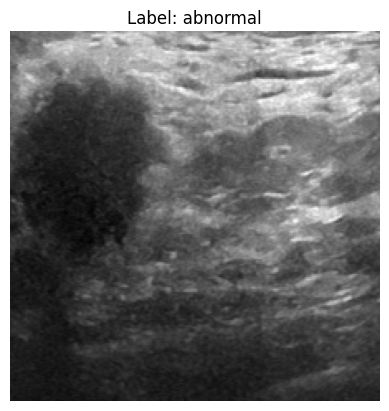

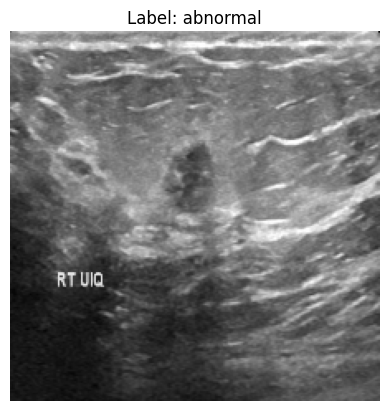

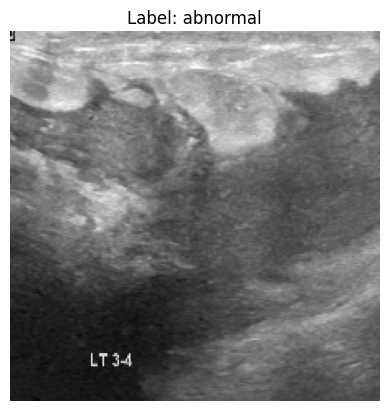

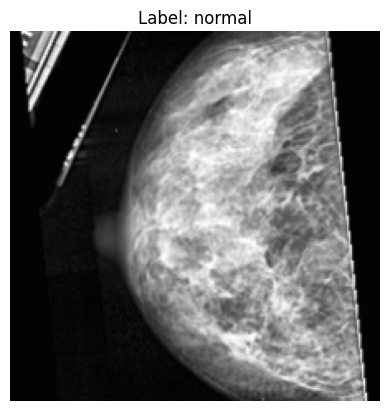

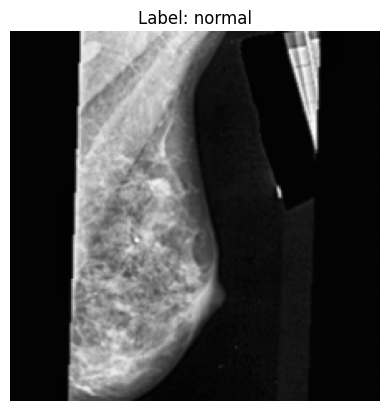

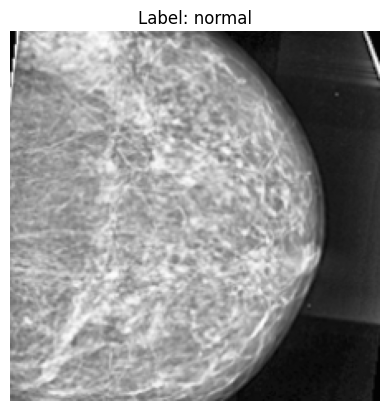

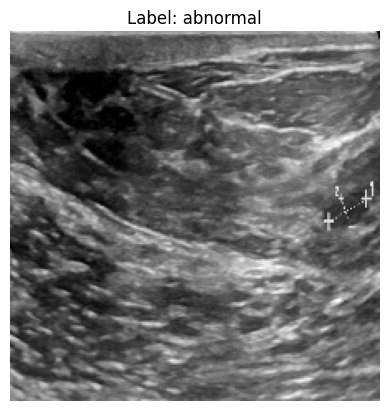

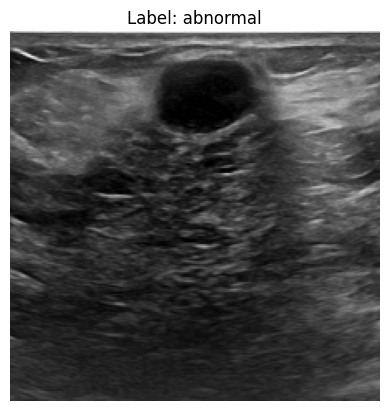

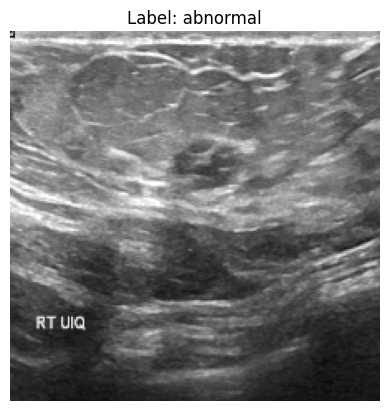

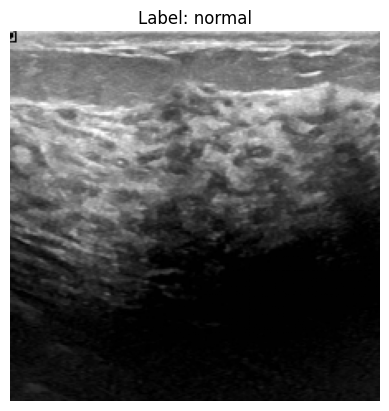

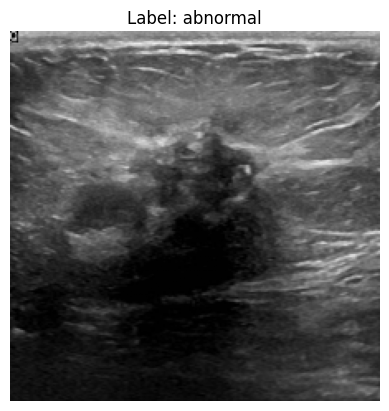

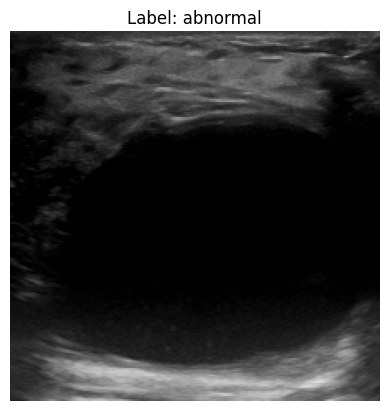

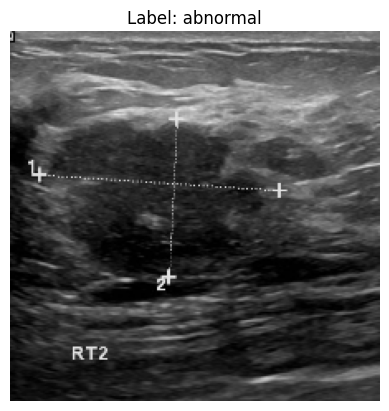

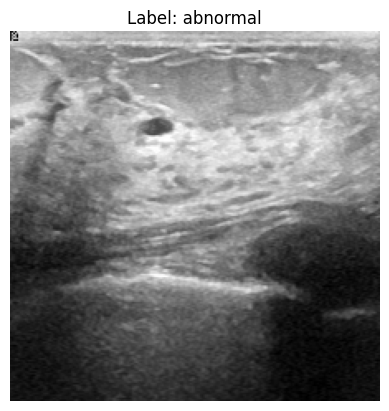

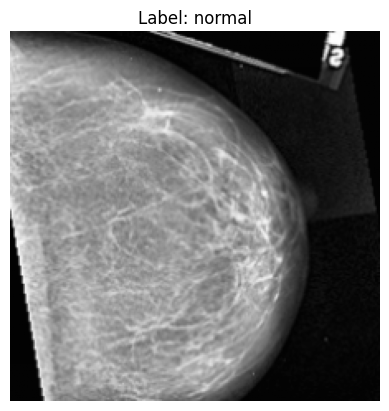

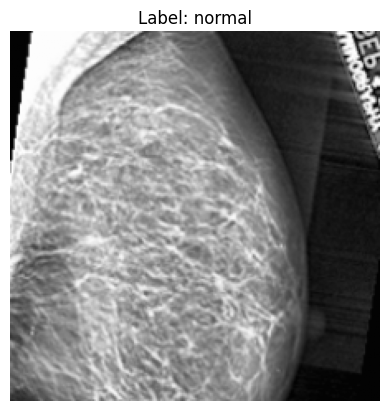

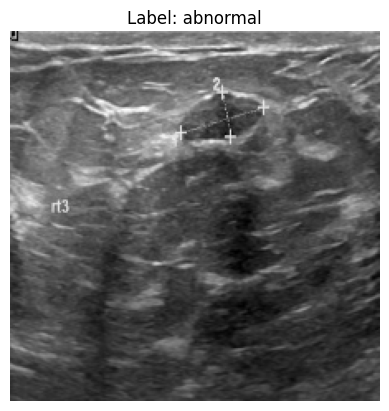

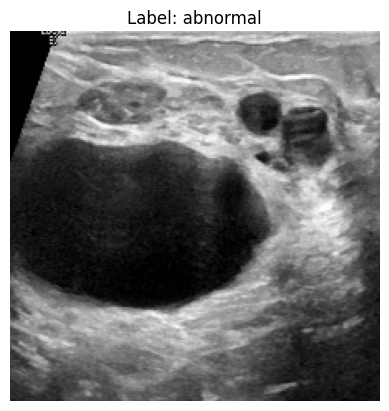

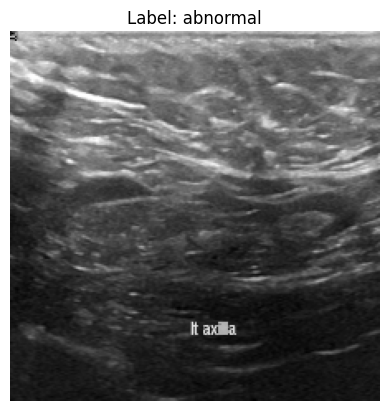

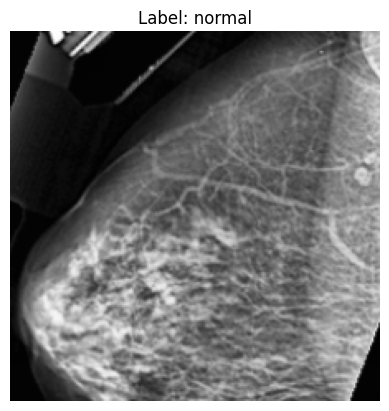

In [11]:
import matplotlib.pyplot as plt

classes = ['normal', 'abnormal']

for i in range(20):
    plt.imshow(X[i])
    plt.title("Label: " + classes[y[i]])
    plt.axis("off")
    plt.show()

In [12]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')   # Binary output
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [14]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=30,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

Epoch 1/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 150s 5s/step - accuracy: 0.8120 - loss: 0.4044 - val_accuracy: 0.8692 - val_loss: 0.2901
Epoch 2/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 127s 4s/step - accuracy: 0.8680 - loss: 0.3298 - val_accuracy: 0.8734 - val_loss: 0.2926
Epoch 3/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 139s 5s/step - accuracy: 0.8659 - loss: 0.2922 - val_accuracy: 0.8734 - val_loss: 0.2891
Epoch 4/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 132s 4s/step - accuracy: 0.8659 - loss: 0.2967 - val_accuracy: 0.8903 - val_loss: 0.2673
Epoch 5/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 131s 4s/step - accuracy: 0.8796 - loss: 0.2731 - val_accuracy: 0.8861 - val_loss: 0.2711
Epoch 6/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 147s 5s/step - accuracy: 0.8860 - loss: 0.2598 - val_accuracy: 0.8861 - val_loss: 0.2430
Epoch 7/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 210s 5s/step - accuracy: 0.8891 - loss: 0.2682 - val_accuracy: 0.8861 - val_loss: 0.2522
Epoch 8/30
30/30 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - accuracy: 0.8923 - loss: 0.2535 - val_accuracy: 0.8819 - v

In [16]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 837ms/step - accuracy: 0.8861 - loss: 0.2430
Accuracy: 0.8860759735107422


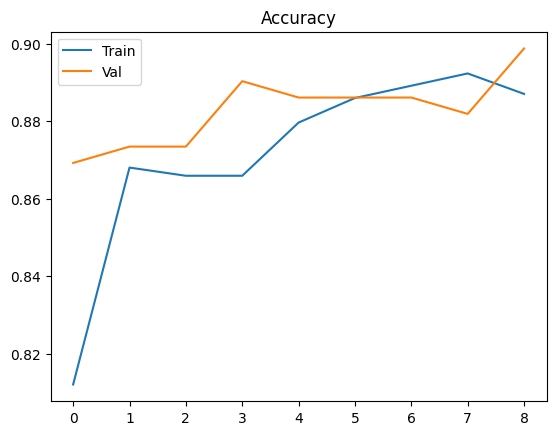

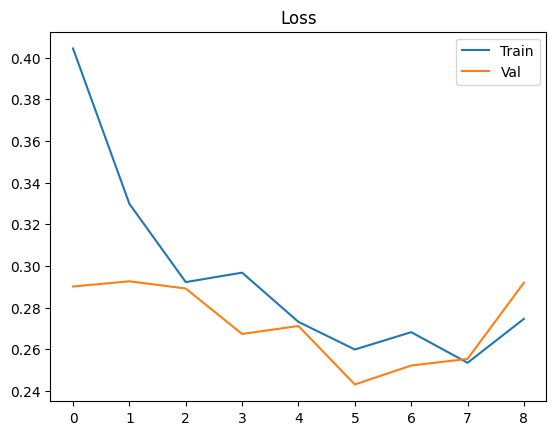

In [17]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Val"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Val"])
plt.show()

8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step


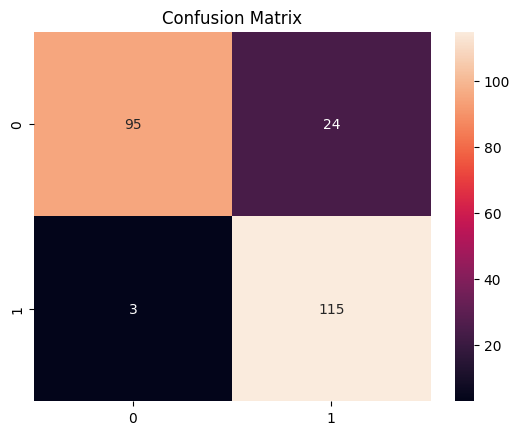

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = (model.predict(X_test) > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

Prediction: Tumor
True: Tumor


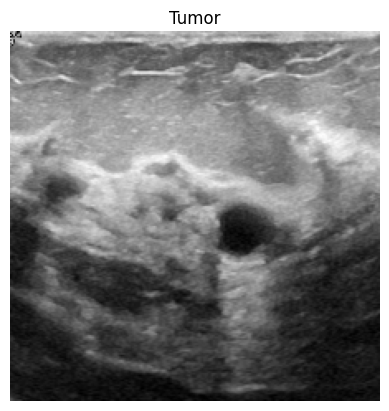

Prediction: Tumor
True: Normal


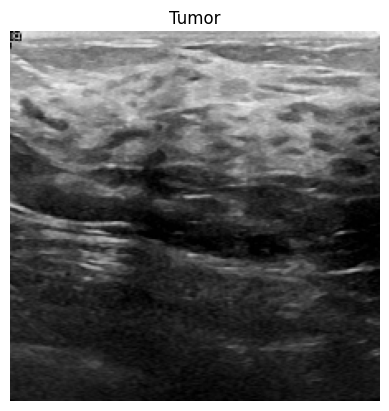

Prediction: Normal
True: Normal


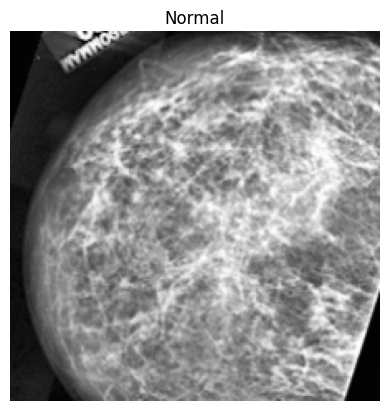

Prediction: Normal
True: Normal


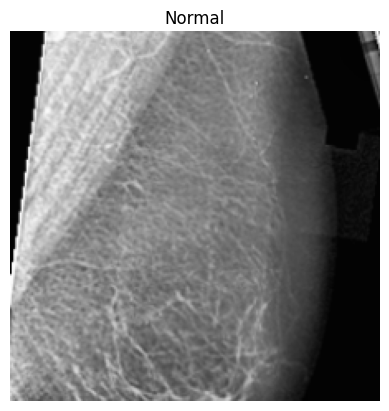

Prediction: Tumor
True: Normal


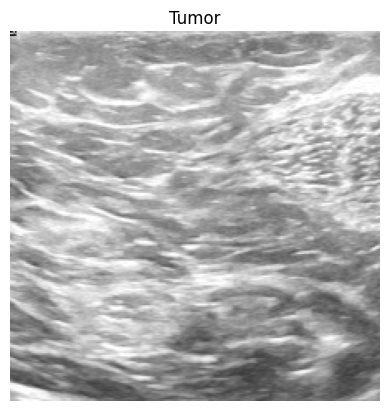

Prediction: Normal
True: Normal


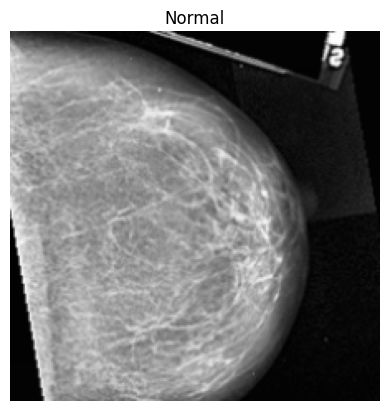

Prediction: Tumor
True: Tumor


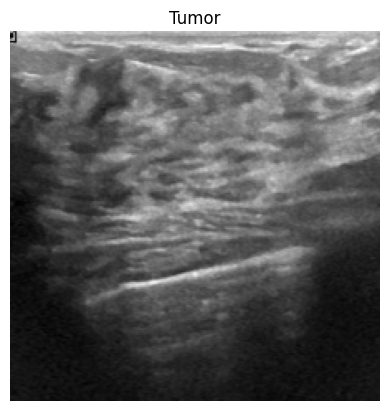

Prediction: Tumor
True: Tumor


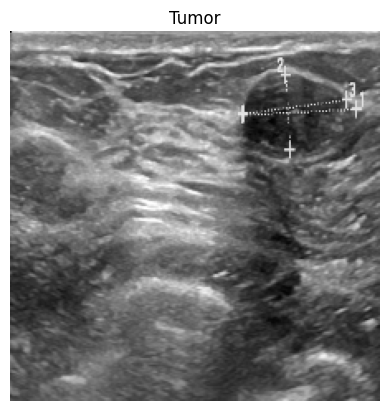

Prediction: Tumor
True: Normal


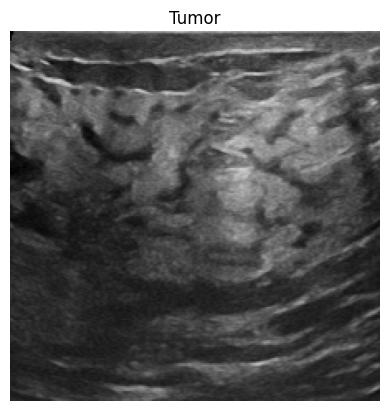

Prediction: Normal
True: Normal


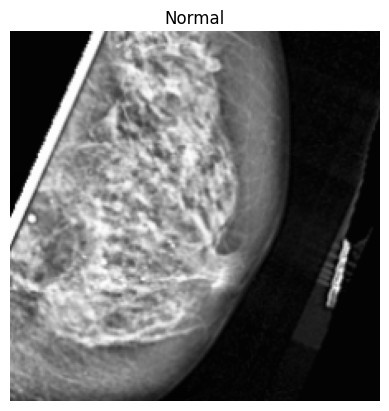

Prediction: Tumor
True: Tumor


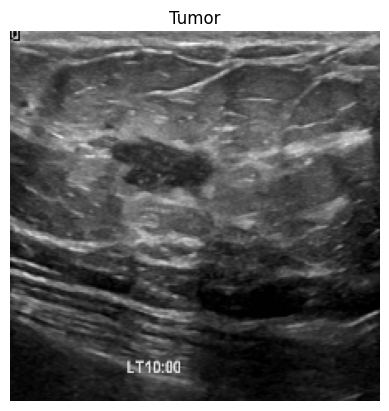

Prediction: Normal
True: Normal


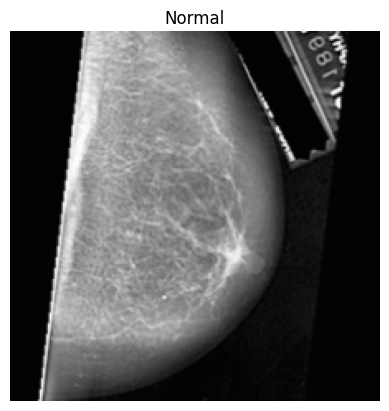

Prediction: Tumor
True: Tumor


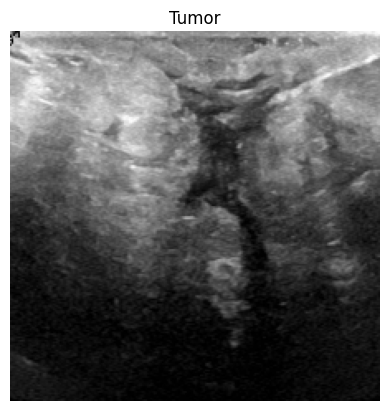

Prediction: Tumor
True: Tumor


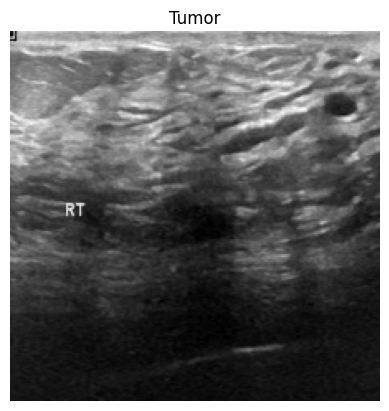

Prediction: Normal
True: Normal


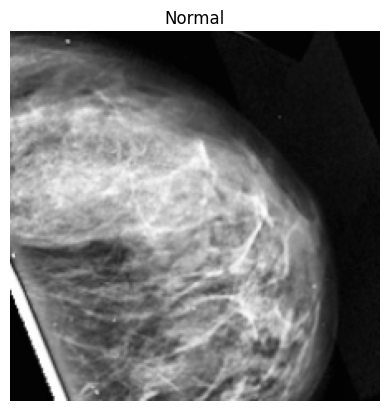

Prediction: Tumor
True: Tumor


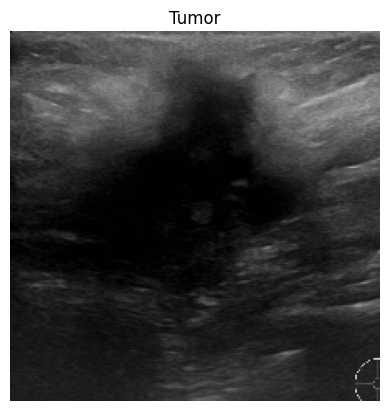

Prediction: Normal
True: Normal


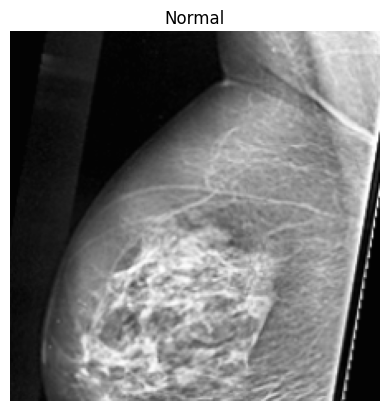

Prediction: Tumor
True: Tumor


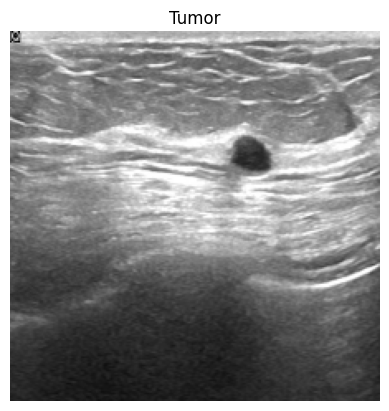

Prediction: Normal
True: Normal


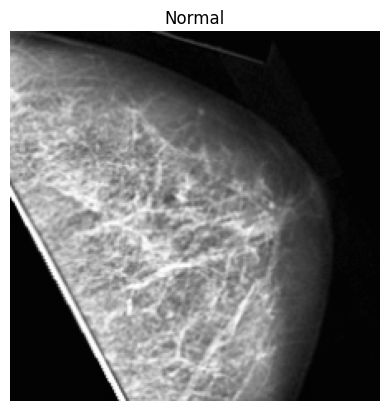

Prediction: Tumor
True: Tumor


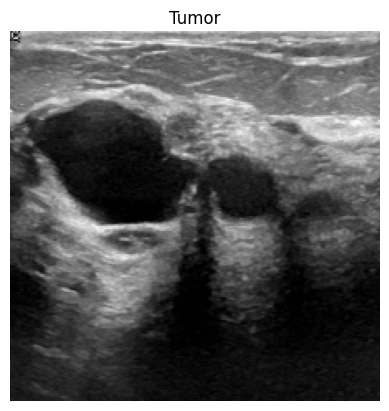

Prediction: Tumor
True: Tumor


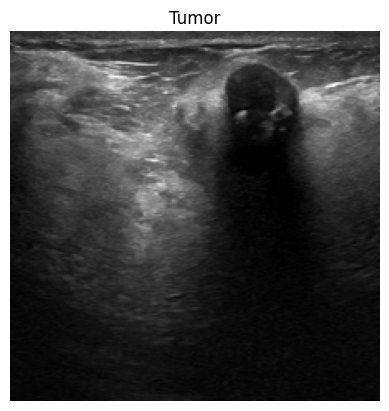

Prediction: Tumor
True: Normal


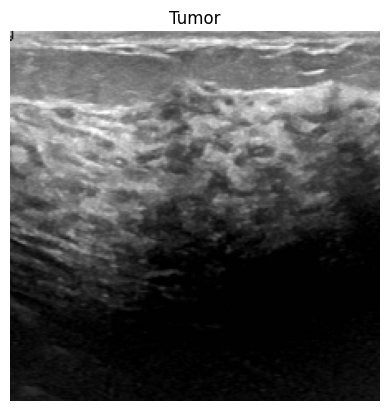

Prediction: Tumor
True: Normal


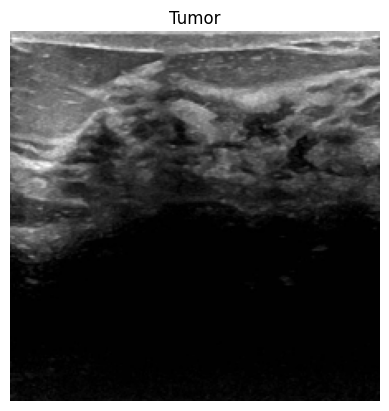

Prediction: Normal
True: Normal


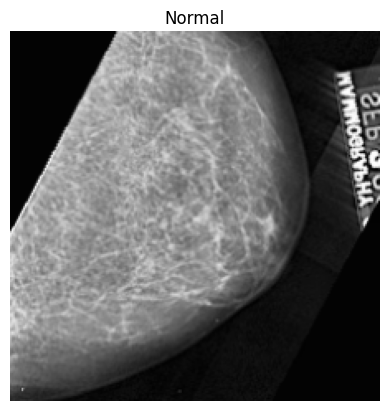

Prediction: Tumor
True: Tumor


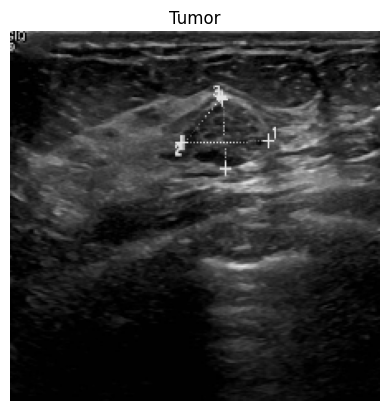

Prediction: Normal
True: Normal


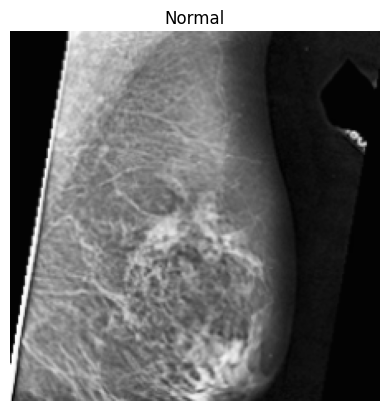

Prediction: Normal
True: Normal


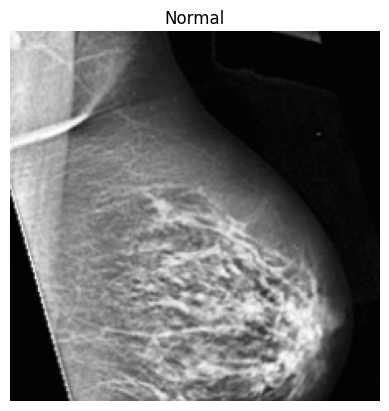

Prediction: Tumor
True: Tumor


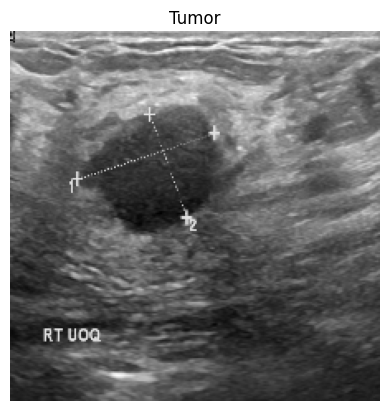

Prediction: Tumor
True: Tumor


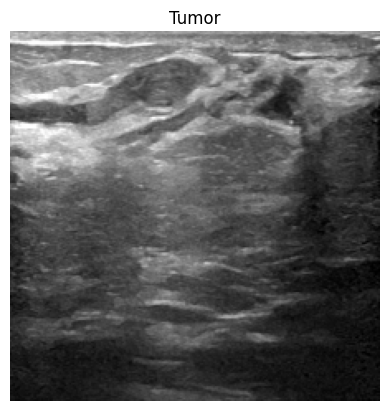

Prediction: Tumor
True: Tumor


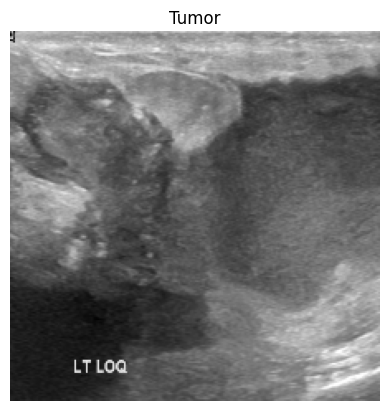

Prediction: Tumor
True: Tumor


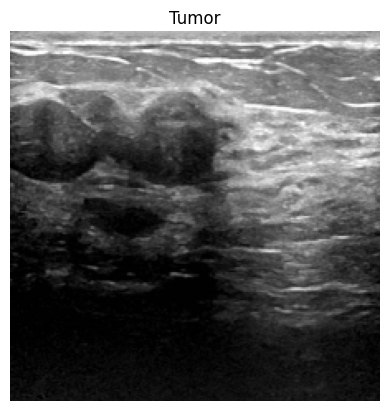

Prediction: Tumor
True: Tumor


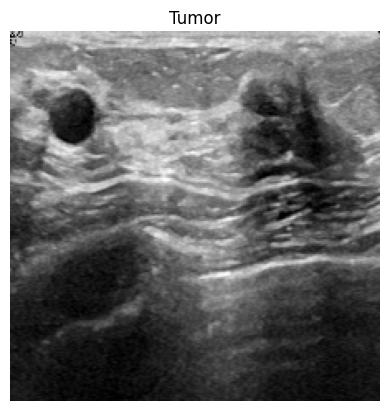

Prediction: Tumor
True: Tumor


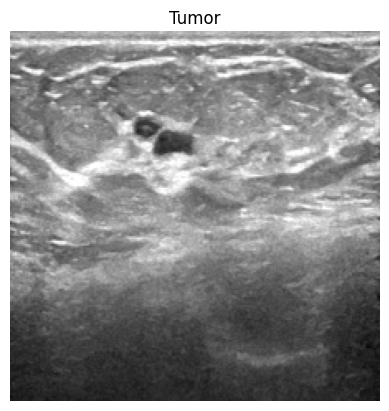

Prediction: Tumor
True: Tumor


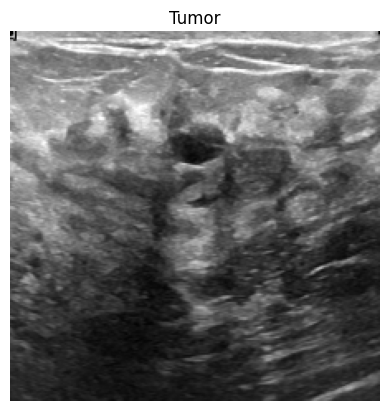

Prediction: Tumor
True: Normal


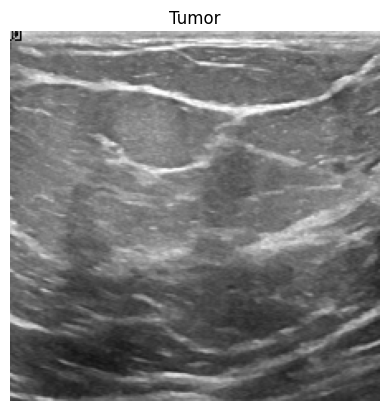

Prediction: Tumor
True: Tumor


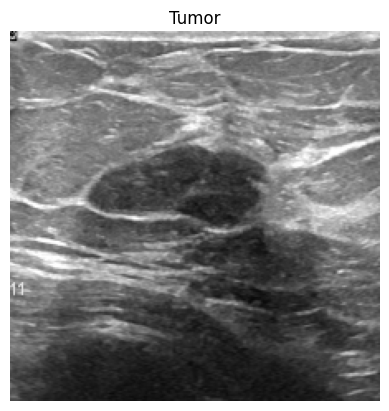

Prediction: Tumor
True: Tumor


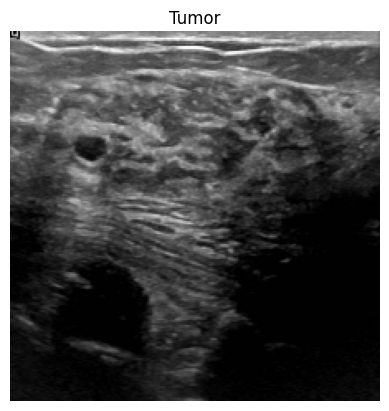

Prediction: Tumor
True: Normal


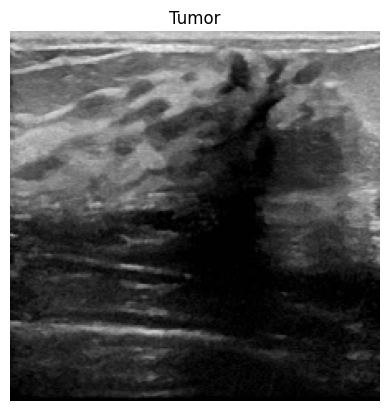

Prediction: Tumor
True: Tumor


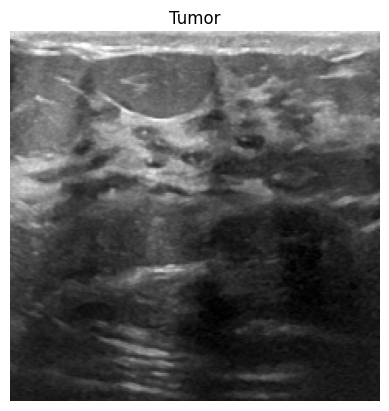

Prediction: Tumor
True: Tumor


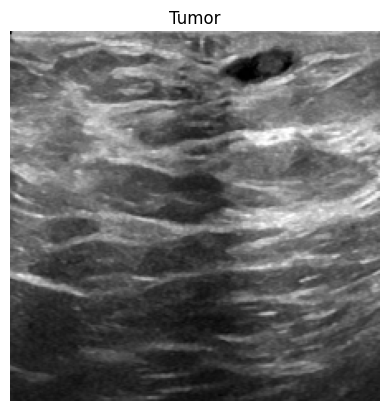

Prediction: Tumor
True: Normal


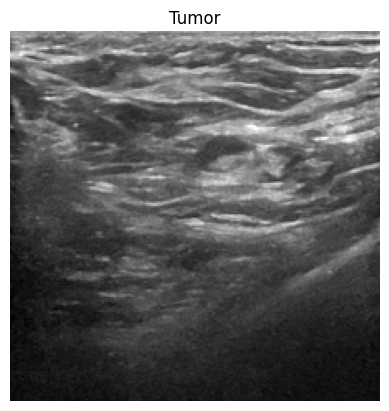

Prediction: Tumor
True: Tumor


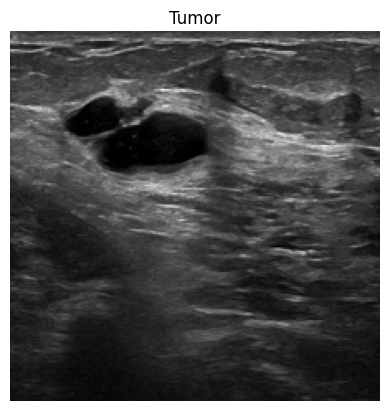

Prediction: Normal
True: Normal


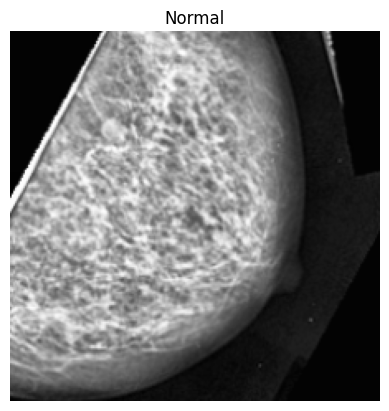

Prediction: Normal
True: Normal


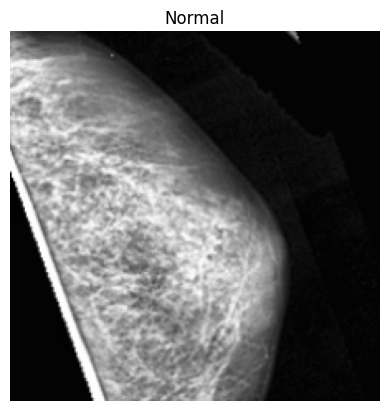

Prediction: Normal
True: Normal


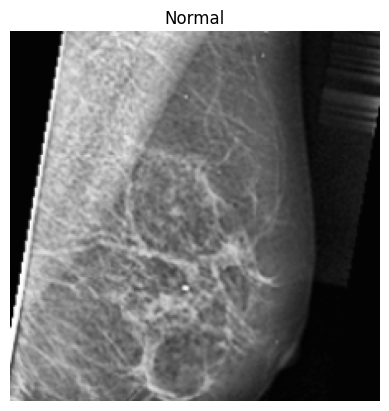

Prediction: Normal
True: Normal


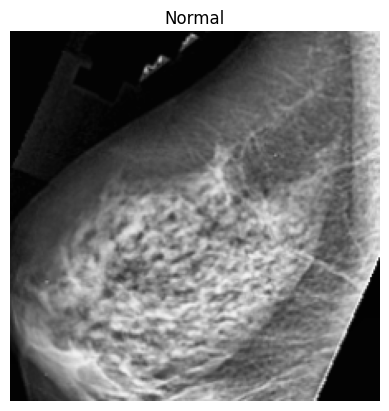

Prediction: Tumor
True: Tumor


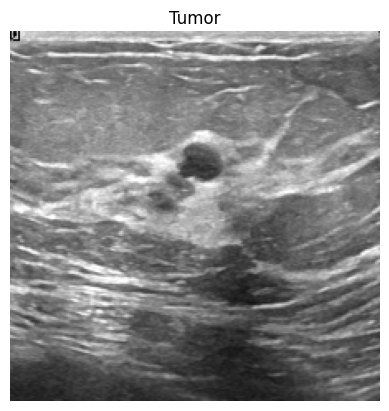

Prediction: Tumor
True: Tumor


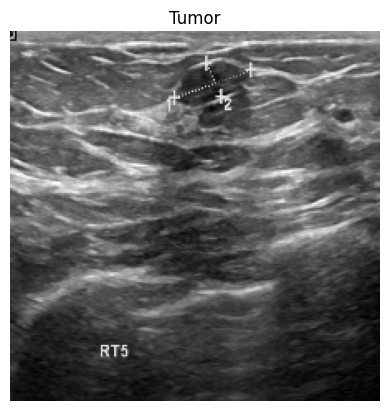

Prediction: Normal
True: Normal


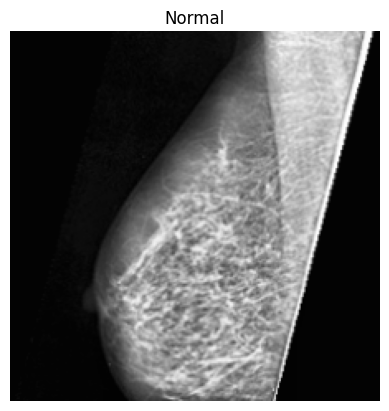

Prediction: Normal
True: Normal


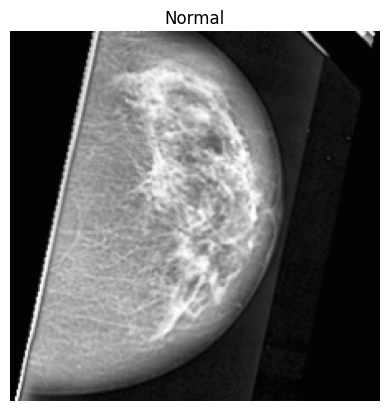

In [19]:
for i in range(min(50, len(X_test))):
    sample = X_test[i].reshape(1, 224, 224, 3)

    pred = model.predict(sample, verbose=0).flatten()[0]

    label = "Tumor" if pred > 0.5 else "Normal"

    print("Prediction:", label)
    print("True:", "Tumor" if y_test[i] == 1 else "Normal")

    # Convert the image back to uint8 before passing to cv2.cvtColor
    display_image = (X_test[i] * 255).astype(np.uint8)
    plt.imshow(cv2.cvtColor(display_image, cv2.COLOR_BGR2RGB))
    plt.title(label)
    plt.axis("off")
    plt.show()

In [20]:
model.save("cnn_model_binary.keras")

In [21]:
from google.colab import files
files.download("cnn_model_binary.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>